<a href="https://colab.research.google.com/github/rfajri27/a555-eda/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BANK CHURNERS - ANALYST**
By : Albertman Barasa

##  **Contents:**

* [1. Imports](#1)
* [2. Loading the dataset](#2)
* [3. Quick look into the dataset](#3)
* [4. Summary statistics](#4)
* [5. Exploratory Data Analysis (EDA)](#5)
* [6. Checking feature correlations](#6)

<a name='1'></a>

## **1. Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


<a name='2'></a>
    
## **2. Loading the Dataset**

In [2]:
customers_df = pd.read_csv("https://raw.githubusercontent.com/allbertmann/BankChurners_Analyst/refs/heads/main/BankChurners.csv")
customers_df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


<a name='3'></a>
## **3. Quick Look into the dataset**

Description of each column in the information dataset :

1. **CLIENTNUM** : A unique identifier for each customer <br>
2. **Attrition_Flag** : The membership status of the customer, indicating whether they are active or have churned <br>
3. **Customer_Age** : The age of the customer <br>
4. **Gender** : The gender of the customer (Male or Female) <br>
5. **Dependent_count** : The number of dependents the customer has <br>
6. **Education_Level** : The highest level of education completed by the customer <br>
7. **Marital_Status** : The marital status of the customer (e.g., Married, Single, Divorced) <br>
8. **Income_Category** : The income category of the customer (e.g., Low, Medium, High) <br>
9. **Card_Category** : The type of credit card the customer holds (e.g., Silver, Gold, Platinum) <br>
10. **Months_on_book** : The duration (in months) the customer has been associated with the bank <br>
11. **Total_Relationship_Count** : The total number of products or services the customer has with the bank (e.g., savings accounts, loans, investments) <br>
12. **Months_Inactive_12_mon** : The number of months in the past 12 months that the customer has been inactive <br>
13. **Contacts_Count_12_mon** : The number of times the customer has contacted the bank in the past 12 months <br>
14. **Credit_Limit** : The credit limit assigned to the customer <br>
15. **Total_Revolving_Bal** : The total revolving balance on the customer's credit card <br>
16. **Avg_Open_To_Buy** : The average available credit for the customer to use <br>
17. **Total_Amt_Chng_Q4_Q1** : The change in the total transaction amount on the credit card between Q4 and Q1 <br>
18. **Total_Trans_Amt** : The total monetary value of transactions made by the customer during a specific period <br>
19. **Total_Trans_Ct** : The total count of transactions made by the customer <br>
20. **Total_Ct_Chng_Q4_Q1** : The change in the total number of transactions on the credit card between Q4 and Q1 <br>
21. **Avg_Utilization_Ratio** : The average credit utilization ratio (calculated as the ratio of credit used to the credit limit) <br>
22. **Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1** : The prediction probability for Class 1 using a Naive Bayes model <br>
23. **Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2** : The prediction probability for Class 2 using a Naive Bayes model

In [3]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [4]:
customers_df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

> Based on the above, we know that our data contains 22 columns, 10,127 rows, and no null values. Let's take a closer look at our data! However, since the column names are too lengthy, we should rename them for better readability.

In [5]:
# Rename column
customers_df.rename(columns={'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1': 'Naive_Bayes_1',
                   'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2': 'Naive_Bayes_2'},
          inplace=True)

In [6]:
customers_df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_1,Naive_Bayes_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [7]:
customers_df.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_1,Naive_Bayes_2
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189,0.996620,0.003377


> By default, custumers_df.head() will display the first five rows. But you can display the rows you want, just pass the integer. Example: `custumers_df.head(10)`. .`tail() will display the last rows

In [8]:
print("Count Duplicates: ", customers_df.duplicated().sum())

Count Duplicates:  0


> Based on the above, our data doesn't have duplicate.

<a name='4'></a>
## **4. Summary statistics**

In [9]:
customers_df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_1,Naive_Bayes_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


In [10]:
customers_df.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,7.080821e+08,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,2.600000e+01,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,1.300000e+01,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1.438300e+03,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.000000e+00,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.000000e+00,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


<a name='5'></a>
## **5. Exploratory Data Analysis (EDA) ⏳**

### **Customers Perspective **

#### 1. What is the distribution of customers who are active and those who have churned from the bank?

In [11]:
customers_df['Attrition_Flag'].value_counts()

,count
Attrition_Flag,
Existing Customer,8500
Attrited Customer,1627


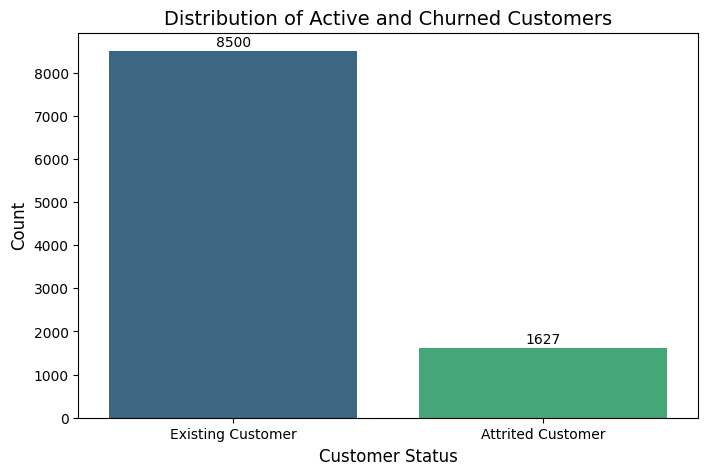

In [12]:
# Count the number of customers in each category
attrition_counts = customers_df['Attrition_Flag'].value_counts()

# Create a bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette='viridis')

# Add titles and labels
plt.title('Distribution of Active and Churned Customers', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Show the counts above the bars
for i, value in enumerate(attrition_counts.values):
    plt.text(i, value + 100, str(value), ha='center', fontsize=10)

# Display the plot
plt.show()

#### 2. What is the age distribution of the customers in the dataset?

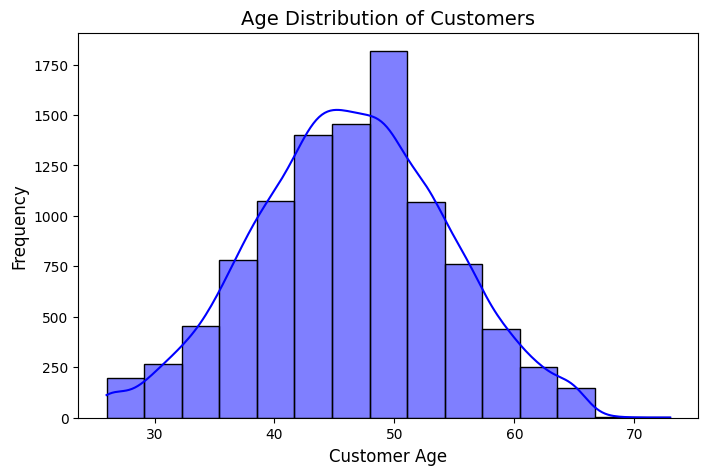

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(customers_df['Customer_Age'], kde=True, color='blue', bins=15)
plt.title('Age Distribution of Customers', fontsize=14)
plt.xlabel('Customer Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

#### 3. How does the average credit limit differ between active and churned customers?

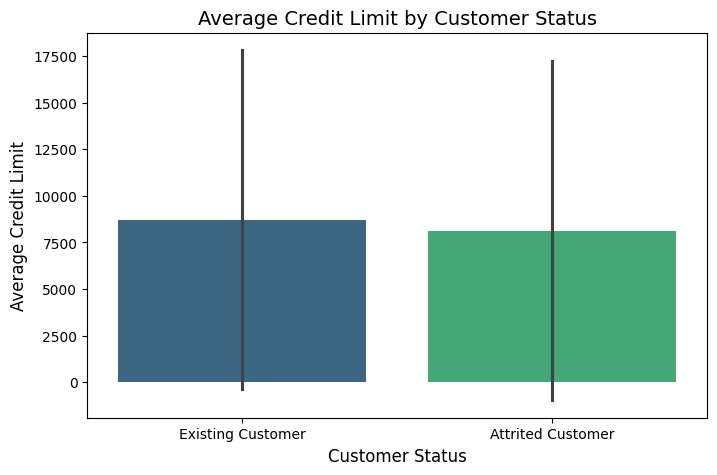

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(data=customers_df, x='Attrition_Flag', y='Credit_Limit', ci='sd', palette='viridis')
plt.title('Average Credit Limit by Customer Status', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Average Credit Limit', fontsize=12)
plt.show()

<Axes: xlabel='Attrition_Flag', ylabel='Credit_Limit'>

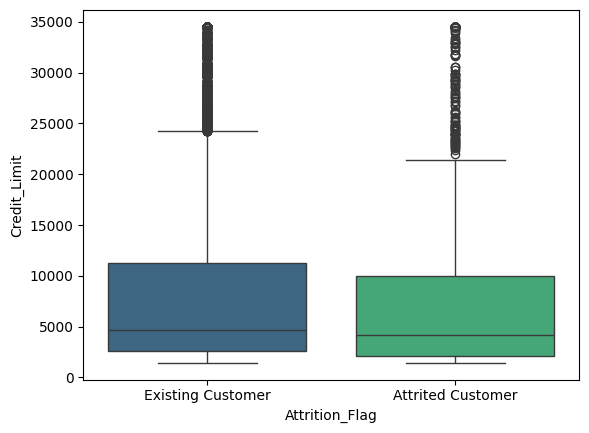

In [15]:
sns.boxplot(data=customers_df, x='Attrition_Flag', y='Credit_Limit', palette='viridis')

#### 4. What is the distribution of education levels among customers? Which level is most common?

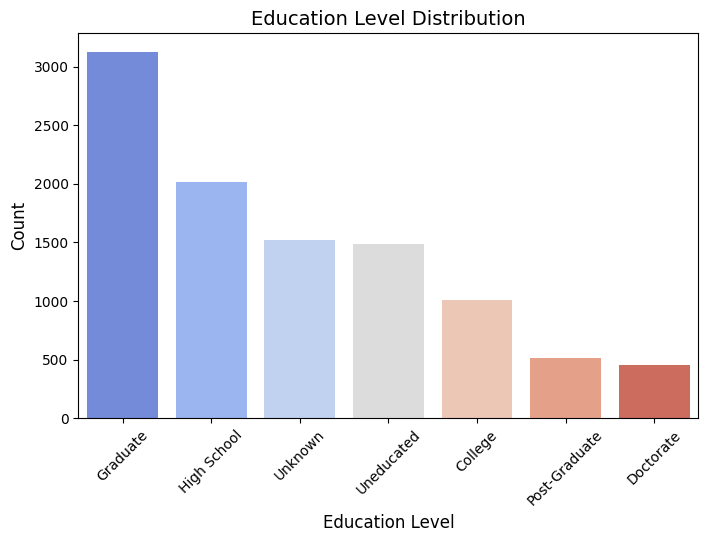

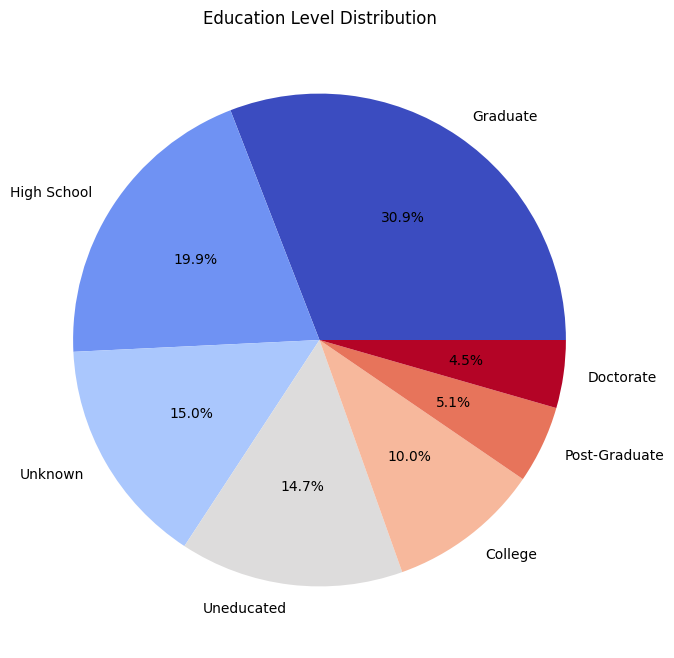

In [16]:
education_counts = customers_df['Education_Level'].value_counts()

# Bar Chart
plt.figure(figsize=(8, 5))
sns.barplot(x=education_counts.index, y=education_counts.values, palette='coolwarm')
plt.title('Education Level Distribution', fontsize=14)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Pie Chart
education_counts.plot.pie(autopct='%1.1f%%', figsize=(8, 8), colormap='coolwarm', title='Education Level Distribution')
plt.ylabel('')  # To remove y-axis label
plt.show()

#### 5. What is the correlation between credit utilization ratio and customer attrition?

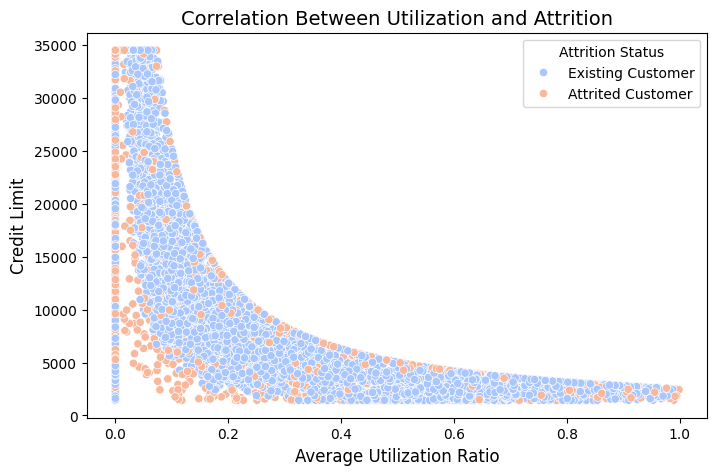

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=customers_df, x='Avg_Utilization_Ratio', y='Credit_Limit', hue='Attrition_Flag', palette='coolwarm')
plt.title('Correlation Between Utilization and Attrition', fontsize=14)
plt.xlabel('Average Utilization Ratio', fontsize=12)
plt.ylabel('Credit Limit', fontsize=12)
plt.legend(title='Attrition Status')
plt.show()

#### 6. How many customers fall into each income category?

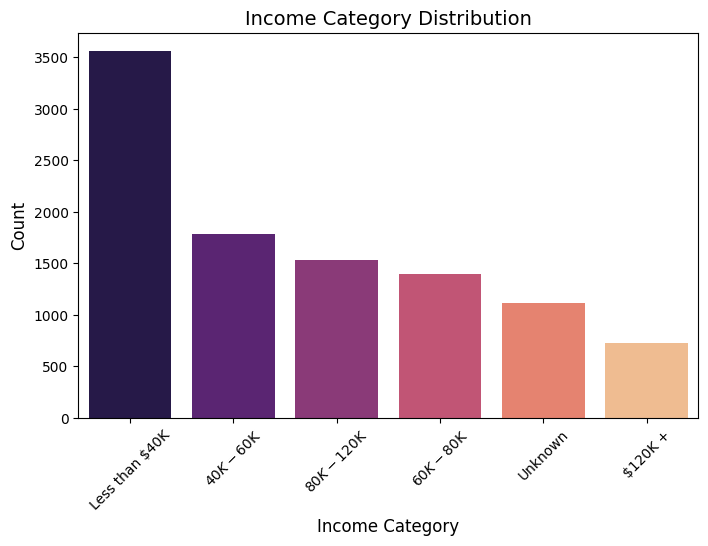

In [18]:
income_counts = customers_df['Income_Category'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=income_counts.index, y=income_counts.values, palette='magma')
plt.title('Income Category Distribution', fontsize=14)
plt.xlabel('Income Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

#### 7. What is the relationship between the number of inactive months in the past year and customer attrition?

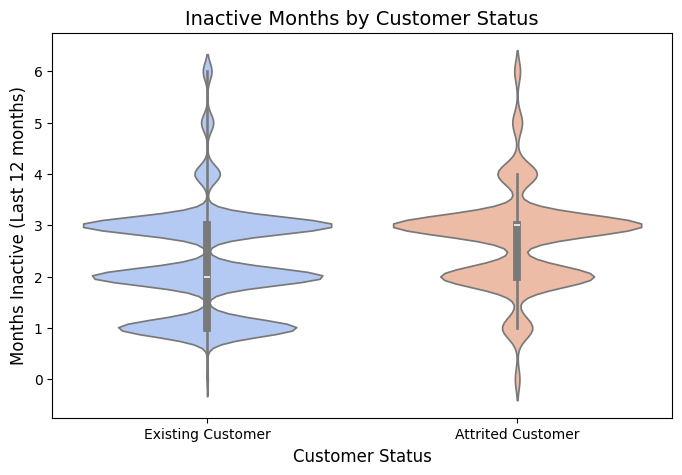

In [19]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=customers_df, x='Attrition_Flag', y='Months_Inactive_12_mon', palette='coolwarm')
plt.title('Inactive Months by Customer Status', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Months Inactive (Last 12 months)', fontsize=12)
plt.show()

<Axes: xlabel='Attrition_Flag', ylabel='Months_Inactive_12_mon'>

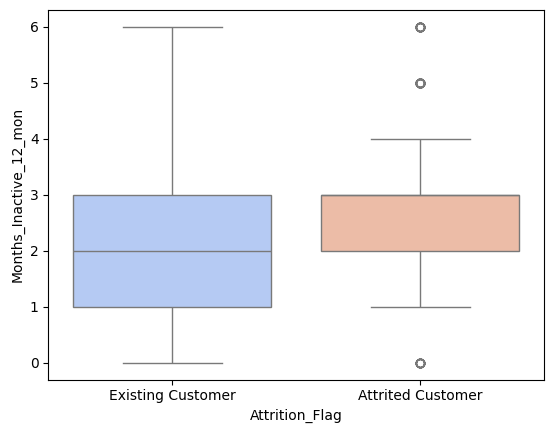

In [20]:
sns.boxplot(data=customers_df, x='Attrition_Flag', y='Months_Inactive_12_mon', palette='coolwarm')

#### 8. Which card category (e.g., Silver, Gold, Platinum) has the highest average total transaction amount?

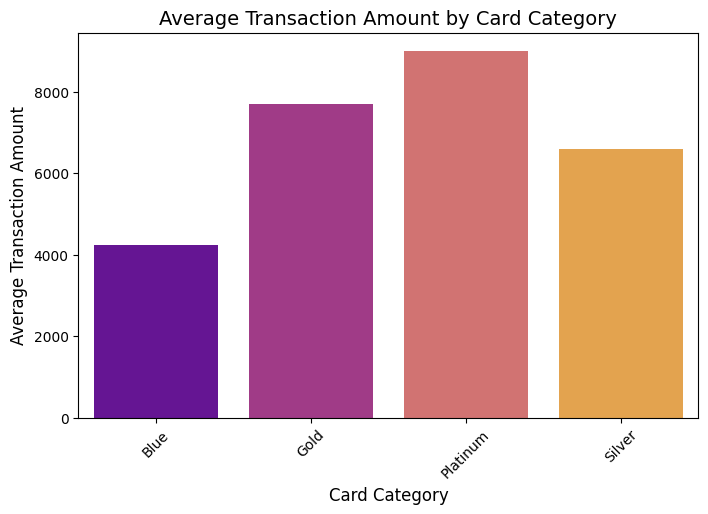

In [21]:
avg_transaction = customers_df.groupby('Card_Category')['Total_Trans_Amt'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_transaction, x='Card_Category', y='Total_Trans_Amt', palette='plasma')
plt.title('Average Transaction Amount by Card Category', fontsize=14)
plt.xlabel('Card Category', fontsize=12)
plt.ylabel('Average Transaction Amount', fontsize=12)
plt.xticks(rotation=45)
plt.show()

#### 9. How does the total number of transactions differ between active and churned customers?

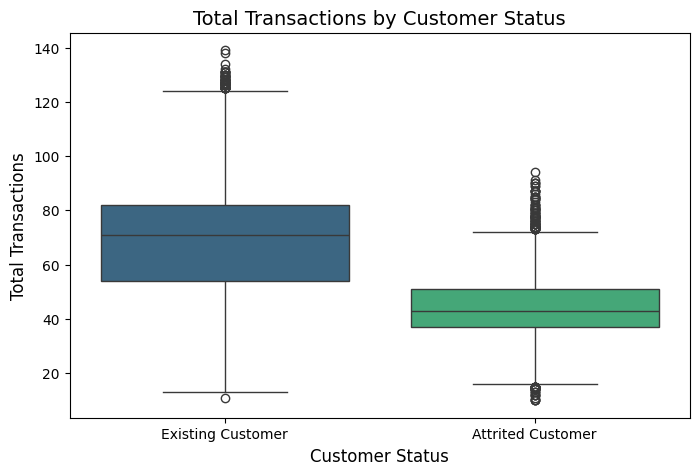

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=customers_df, x='Attrition_Flag', y='Total_Trans_Ct', palette='viridis')
plt.title('Total Transactions by Customer Status', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Total Transactions', fontsize=12)
plt.show()

#### 10. Is there a noticeable pattern between the number of contacts in the past year and customer attrition?

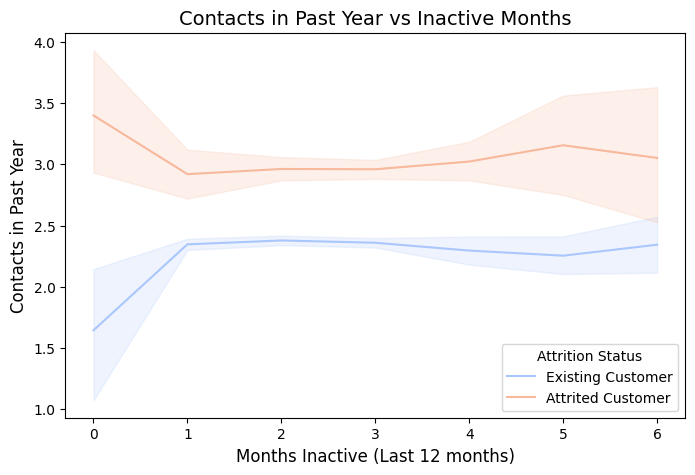

In [23]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=customers_df, x='Months_Inactive_12_mon', y='Contacts_Count_12_mon', hue='Attrition_Flag', palette='coolwarm')
plt.title('Contacts in Past Year vs Inactive Months', fontsize=14)
plt.xlabel('Months Inactive (Last 12 months)', fontsize=12)
plt.ylabel('Contacts in Past Year', fontsize=12)
plt.legend(title='Attrition Status')
plt.show()

#### 11. What is the marital status distribution of the customers, and how does it relate to attrition?

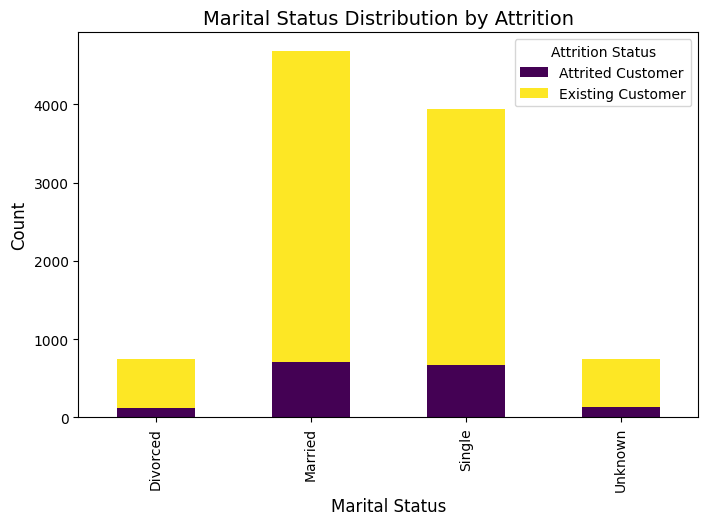

In [24]:
marital_attrition = customers_df.groupby(['Marital_Status', 'Attrition_Flag']).size().unstack()

# Stacked Bar Chart
marital_attrition.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
plt.title('Marital Status Distribution by Attrition', fontsize=14)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Attrition Status')
plt.show()

### **Bank Perspective **

#### Does age distribution affect attrition?

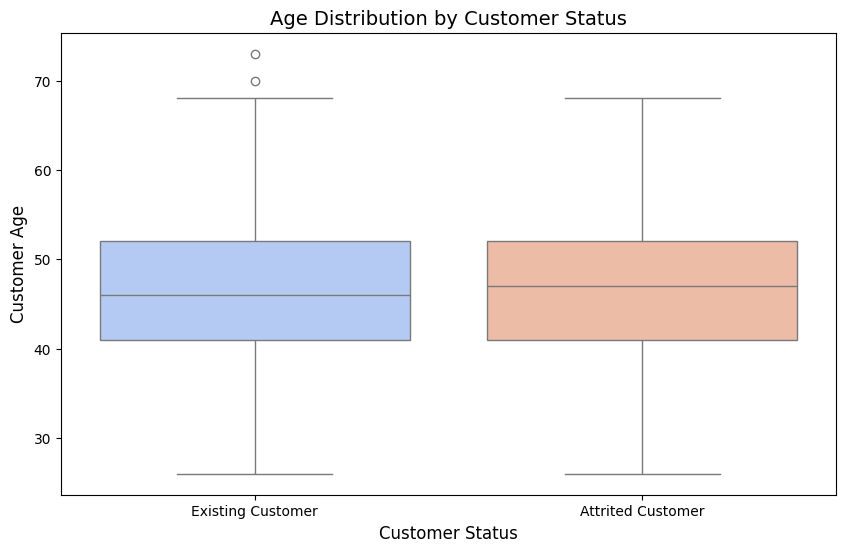

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=customers_df, x='Attrition_Flag', y='Customer_Age', palette='coolwarm')
plt.title('Age Distribution by Customer Status', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Customer Age', fontsize=12)
plt.show()

#### Is the number of contacts in the last 12 months related to attrition?

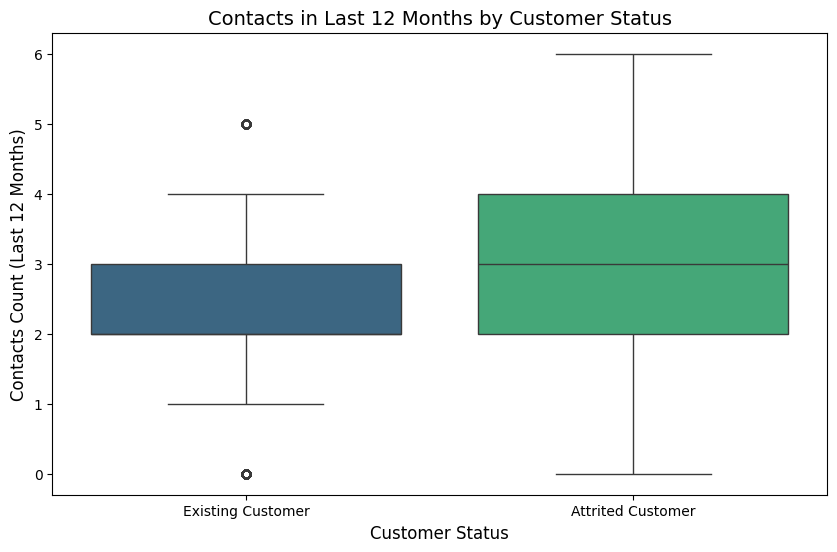

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=customers_df, x='Attrition_Flag', y='Contacts_Count_12_mon', palette='viridis')
plt.title('Contacts in Last 12 Months by Customer Status', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Contacts Count (Last 12 Months)', fontsize=12)
plt.show()

#### Are customers with high card usage ratios more likely to churn?

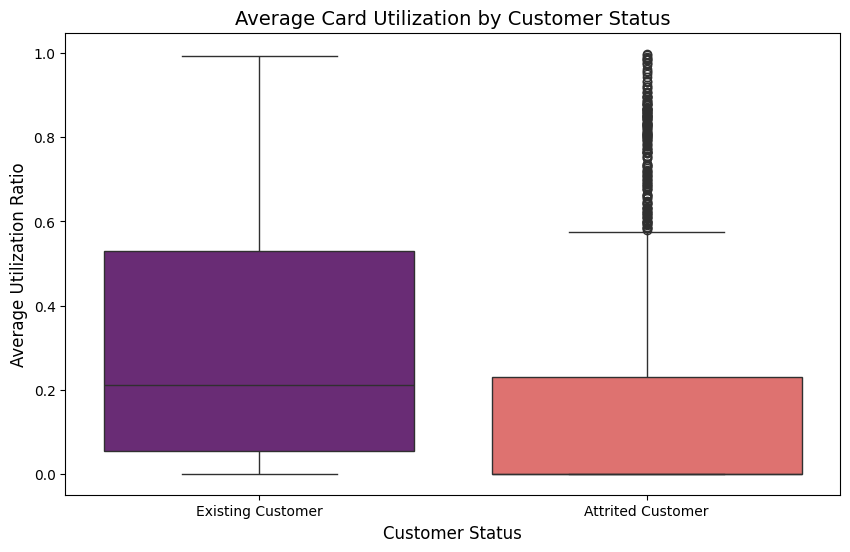

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=customers_df, x='Attrition_Flag', y='Avg_Utilization_Ratio', palette='magma')
plt.title('Average Card Utilization by Customer Status', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Average Utilization Ratio', fontsize=12)
plt.show()

#### Does income category affect attrition?

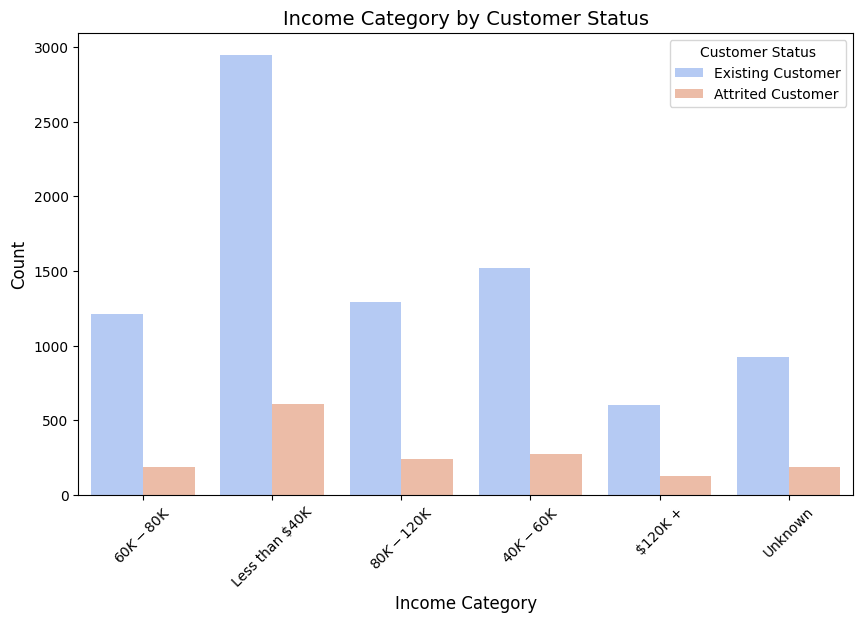

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(data=customers_df, x='Income_Category', hue='Attrition_Flag', palette='coolwarm')
plt.title('Income Category by Customer Status', fontsize=14)
plt.xlabel('Income Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Customer Status')
plt.show()


#### How long does the average churn customer use a bank's services?

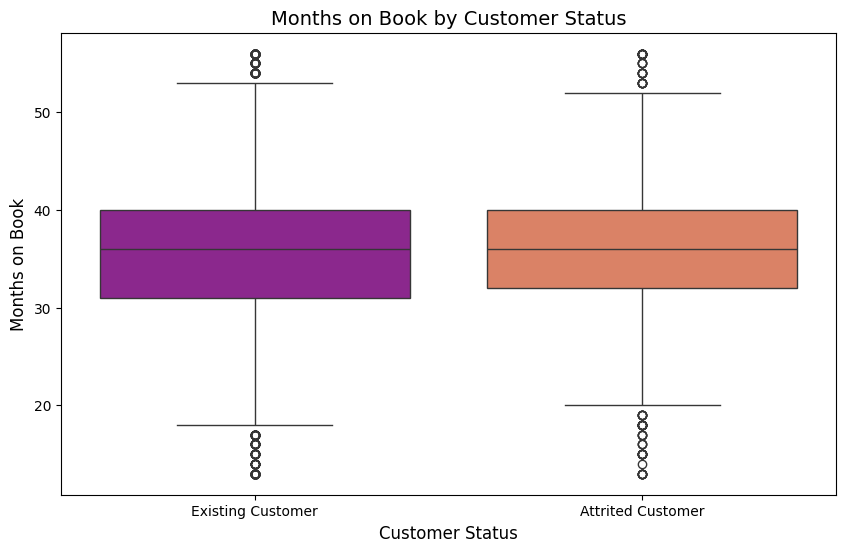

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=customers_df, x='Attrition_Flag', y='Months_on_book', palette='plasma')
plt.title('Months on Book by Customer Status', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Months on Book', fontsize=12)
plt.show()


<a name='6'></a>

## **6. Checking Correlating Features**

Checking correlation can help you to see the similarity between features. If two features correlate, that means they contain the same information and if one of them is removed, the analysis/model can be less affected.

In [30]:
customers_df.dtypes

,0
CLIENTNUM,int64
Attrition_Flag,object
Customer_Age,int64
Gender,object
Dependent_count,int64
Education_Level,object
Marital_Status,object
Income_Category,object
Card_Category,object
Months_on_book,int64


In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
customers_df['Attrition_Flag'] = le.fit_transform(customers_df['Attrition_Flag'])

In [32]:
## drop non numerical coloumns
customers_df = customers_df.select_dtypes(include=['number'])

In [33]:
correlation = customers_df.corr()

In [34]:
correlation['Attrition_Flag']

,Attrition_Flag
CLIENTNUM,0.046430
Attrition_Flag,1.000000
Customer_Age,-0.018203
Dependent_count,-0.018991
Months_on_book,-0.013687
Total_Relationship_Count,0.150005
Months_Inactive_12_mon,-0.152449
Contacts_Count_12_mon,-0.204491
Credit_Limit,0.023873
Total_Revolving_Bal,0.263053


If you want to check how the features correlate with the label (`Attrition_Flag`, just for example), here is how to do it:

<Axes: >

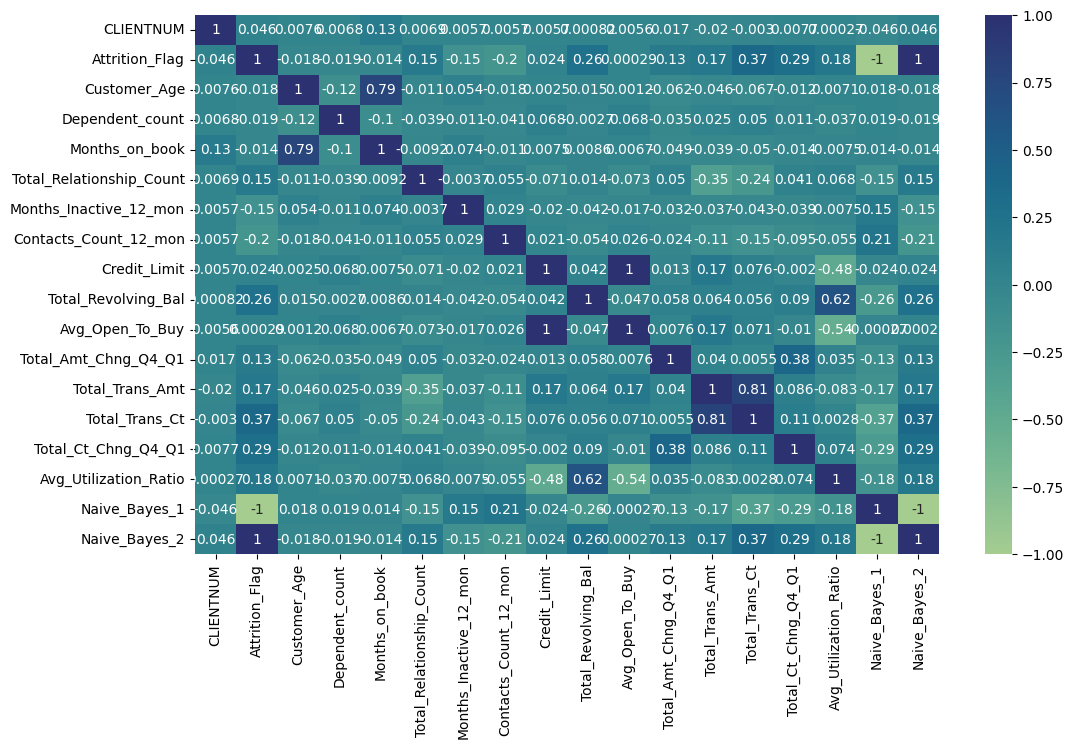

In [35]:
#### Visualizing correlation

plt.figure(figsize=(12,7))

sns.heatmap(correlation,annot=True,cmap='crest')